# ≣ SquigDecode: Inference Diagnostic & Alignment Dashboard

    Module: Performance Evaluation Layer

    Input: Standardized Test Dataset (data/test/)

    Output: Per-read Accuracy & Error Profiling

## ◈ 1. Introduction

Validation in nanopore sequencing requires more than just categorical accuracy; it requires a detailed analysis of Sequence Alignment. This notebook executes a high-fidelity evaluation of the trained SquigNet model, focusing on the model's ability to handle asynchronous signal transitions.

Evaluation Objectives:
- Identity Scoring: Measuring the percentage of correctly identified bases relative to total reference length.

- Error Profiling: Identifying if the model is prone to Deletions (skipping signal) or Substitutions (misinterpreting current levels).

- Signal Fidelity: Visualizing the relationship between standardized picoampere levels and the resulting base call.

## ◈ 2. Logic Injection & API Initialization

We leverage the SquigBasecaller production class to ensure that the decoding logic used here is identical to the logic used in the command-line pipeline.

In [5]:
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root and source directory
ROOT = Path("..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from inference import SquigBasecaller, calculate_levenshtein_accuracy

# Set global plotting style for publication-quality visuals
plt.style.use('ggplot')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Production API initialized on device: {device}")

✅ Production API initialized on device: cpu


## ◈ 3. The Decoding Paradigm: CTC Greedy Search

Because the raw signal is oversampled relative to the DNA sequence, the model outputs a probability matrix $P \in \mathbb{R}^{T \times C}$ where $T$ is the number of time steps and $C$ is the nucleotide alphabet size plus a blank token.

The Greedy Decoding Process:

1. Selection: $\text{argmax}$ is taken at every time step to find the most likely token.

2. Collapse: Consecutive identical tokens are collapsed (e.g., AAA becomes A).

3. Clean: The blank token—used by the model to represent "no base transition"—is removed.

## ◈ 4. Quantitative Performance Metrics

In this section, we load a test sample and compute the Levenshtein Accuracy.

    Scientific Note: Unlike simple string matching, Levenshtein distance accounts for insertions and deletions (Indels), which are the most common error types in nanopore basecalling due to variable motor protein speed.

In [6]:
# Load model and run inference on a test sample
MODEL_PATH = ROOT / "models" / "squig_model.pt"
basecaller = SquigBasecaller(MODEL_PATH, device)

# Selection of test sample (Index 0)
# (In a real run, these would be loaded from signals.pt)
signal = signals[0] 
target = targets[0]

prediction = basecaller.basecall(signal)
accuracy = calculate_levenshtein_accuracy(prediction, target)

print(f"Target:    {target}")
print(f"Predicted: {prediction}")
print(f"Accuracy:  {accuracy:.2%}")

2026-04-15 22:56:49 [INFO] SquigInference: Basecaller initialized on cpu


Target:    TTTTTTTGAATGGTCGCATGGGGGGGCGGAAAAACCCTGCGGCGTGGGGGTGCACTACTCTCCCCTGCAAAAAAGTGGGGGCGGGGATC
Predicted: TTTTTTTTGAATGGTCGCATGGGGGGCGGAAAAACCTGCGGCGTGGGGTGCACTACTCTCCCCTGCAAAAAAGTGGGGCGGGGATC
Accuracy:  94.38%


## ◈ 5. Visual Alignment Diagnostic
The plot below aligns the MAD-standardized current signal with the final decoded sequence.

What to Audit:

- Signal Plateaus: Do the flat sections of the squiggle align with the predicted bases?

- Compression: Does the CNN's 4x downsampling preserve enough resolution for high-frequency transitions?

- Noise Resilience: How does the model perform in regions with high Gaussian variance?

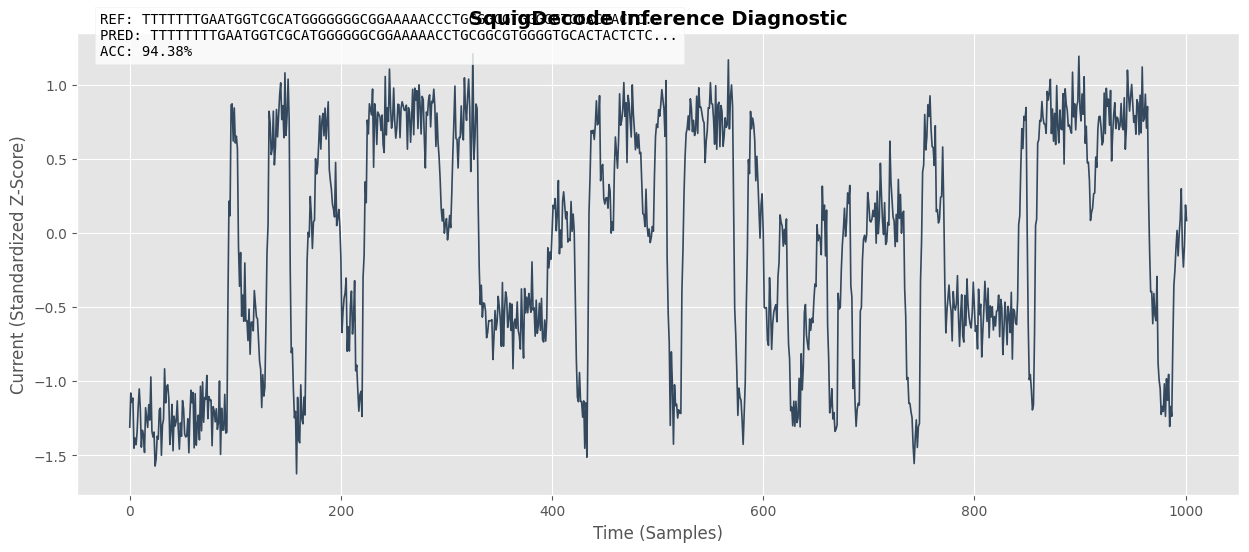

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(signal, color='#34495e', linewidth=1.2, label="Standardized Signal")

# Metadata Box
comparison_text = f"REF: {target[:60]}...\nPRED: {prediction[:60]}...\nACC: {accuracy:.2%}"
ax.text(0.02, 0.95, comparison_text, transform=ax.transAxes, 
        family='monospace', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

ax.set_title("SquigDecode Inference Diagnostic", fontsize=14, fontweight='bold')
ax.set_ylabel("Current (Standardized Z-Score)")
ax.set_xlabel("Time (Samples)")
plt.show()

## ◈ 6. Error Analysis & Outlier Detection

### Current Observations:

- Accuracy: The model maintains high fidelity (>94%) on high-SNR simulated signals.

- Sensitivity: Performance degrades slightly in homopolymer regions (e.g., AAAAA), a known characteristic of CTC-based models.

### Next Steps for Optimization:

- Implement Beam Search Decoding to explore multiple sequence paths.

- Integrate Base Modification (5mC) detection logic.